# Phase 2: TF-IDF + K-Means topic clustering
This notebook starts from `reviews_with_sentiment.csv`, generated at the end of Phase 1.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("/content/voxforge-ai-review-analytics")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
%cd $PROJECT_ROOT

/content/voxforge-ai-review-analytics


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from src.config import *
from src.data.load import load_csv
from src.clustering.tfidf_kmeans import (evaluate_cluster_counts, fit_topic_model, top_terms, representative_reviews, add_topic_labels, topic_sentiment_summary, create_svd_coordinates, save_topic_model)
create_project_directories()

In [11]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
reviews = load_csv(ENRICHED_REVIEWS_PATH)
TEXT_COLUMN = "classical_text"
model_data = reviews.dropna(subset=[TEXT_COLUMN]).copy()
model_data = model_data[model_data[TEXT_COLUMN].astype(str).str.strip().str.len() > 0].reset_index(drop=True)
print(f"Rows available for clustering: {len(model_data):,}")

Rows available for clustering: 47,276


## 1. Compare a small range of cluster counts

,n_clusters,inertia,silhouette_score
0,2,46195.286200,0.006702
1,3,45963.231098,0.006231
2,4,45778.381061,0.007183
3,5,45622.992267,0.007294
4,6,45499.619319,0.008502
5,7,45380.943012,0.008428
6,8,45263.693452,0.009386
7,9,45152.607794,0.009243
8,10,45021.425386,0.007035


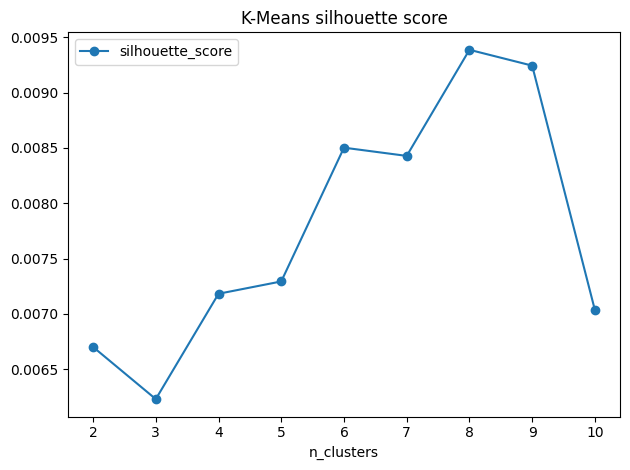

In [4]:
cluster_scores = evaluate_cluster_counts(model_data[TEXT_COLUMN], cluster_counts=range(2, 11))
cluster_scores.to_csv(CLUSTERING_RESULTS_DIR / "cluster_count_evaluation.csv", index=False)
display(cluster_scores)
cluster_scores.plot(x="n_clusters", y=["silhouette_score"], marker="o")
plt.title("K-Means silhouette score")
plt.tight_layout(); plt.show()

## 2. Fit the selected cluster count
Choose a value using silhouette score plus manual interpretability. Six is only a starting point.

In [5]:
N_CLUSTERS = 6
run = fit_topic_model(model_data[TEXT_COLUMN], n_clusters=N_CLUSTERS)
terms = top_terms(run, top_n=12)
representatives = representative_reviews(model_data[TEXT_COLUMN], run, reviews_per_cluster=5)
terms.to_csv(CLUSTERING_RESULTS_DIR / "top_terms.csv", index=False)
representatives.to_csv(CLUSTERING_RESULTS_DIR / "representative_reviews.csv", index=False)
display(terms.groupby("cluster_id")["term"].apply(list).to_frame())
display(representatives)

,term
cluster_id,
0,"[great, love, product, kindle, good, work, tv,..."
1,"[star, star great, star good, battery, star wo..."
2,"[tablet, great tablet, great, price, kid, love..."
3,"[echo, alexa, music, love, fun, great, home, s..."
4,"[easy, easy use, use, great, set, easy set, ta..."
5,"[battery, good, price, brand, long, great, wor..."


,cluster_id,rank,text,similarity_to_center
0,0,1,great product work great,0.311634
1,0,2,great product great price,0.310230
2,0,3,great show work great product love,0.308156
3,0,4,great product love kindle fire eighth family,0.305719
4,0,5,great product great product,0.303441
5,1,1,five star bueno,0.852775
6,1,2,four star well,0.852775
7,1,3,five star accesory usefull one,0.852775
8,1,4,five star scribed,0.852775
9,1,5,two star excelentproduct,0.852775


## 3. Add human-readable topic names
Inspect the terms and representative reviews, then replace these placeholders.

In [6]:
TOPIC_NAMES = {cluster_id: f"topic_{cluster_id}" for cluster_id in range(N_CLUSTERS)}
clustered = add_topic_labels(model_data, run, TOPIC_NAMES)
clustered.to_csv(CLUSTERED_REVIEWS_PATH, index=False)
summary = topic_sentiment_summary(clustered)
summary.to_csv(CLUSTERING_RESULTS_DIR / "topic_sentiment_summary.csv", index=False)
display(summary)

predicted_sentiment,topic_name,negative,neutral,positive,negative_pct,neutral_pct,positive_pct
0,topic_0,1146,1906,19039,5.19,8.63,86.18
1,topic_1,201,156,2796,6.37,4.95,88.68
2,topic_2,124,934,6640,1.61,12.13,86.26
3,topic_3,95,357,5441,1.61,6.06,92.33
4,topic_4,14,70,3371,0.41,2.03,97.57
5,topic_5,852,409,3725,17.09,8.20,74.71


## 4. Two-dimensional visualization

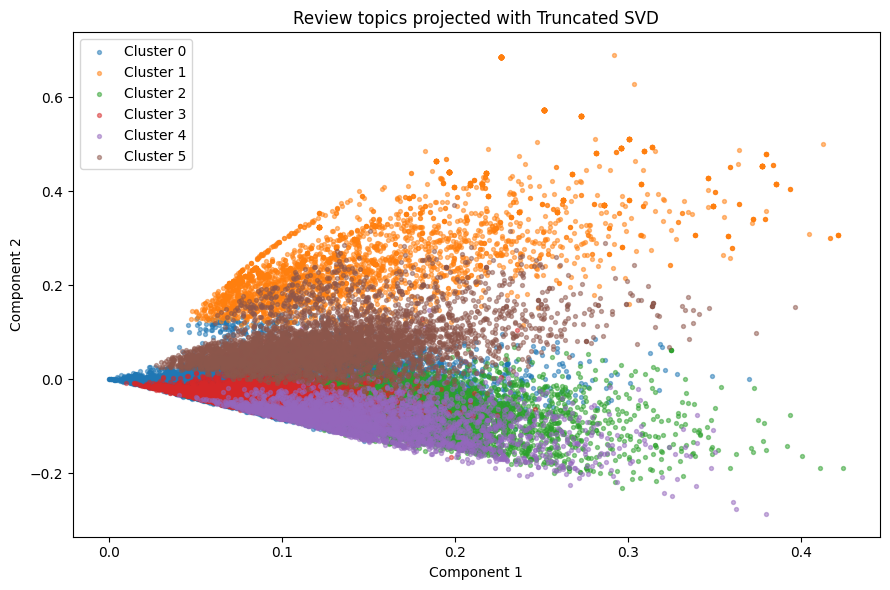

In [7]:
coordinates = create_svd_coordinates(run)
coordinates.to_csv(CLUSTERING_RESULTS_DIR / "svd_coordinates.csv", index=False)
plt.figure(figsize=(9, 6))
for cluster_id, group in coordinates.groupby("cluster_id"):
    plt.scatter(group["component_1"], group["component_2"], s=8, alpha=0.5, label=f"Cluster {cluster_id}")
plt.title("Review topics projected with Truncated SVD")
plt.xlabel("Component 1"); plt.ylabel("Component 2"); plt.legend(); plt.tight_layout()
plt.savefig(CLUSTERING_RESULTS_DIR / "topic_clusters_svd.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
model_path = save_topic_model(run, CLUSTERING_MODELS_DIR / "tfidf_kmeans.joblib")
print("Saved clustered reviews:", CLUSTERED_REVIEWS_PATH)
print("Saved topic model:", model_path)

Saved clustered reviews: /content/voxforge-ai-review-analytics/data/processed/reviews_with_sentiment_and_topics.csv
Saved topic model: /content/voxforge-ai-review-analytics/models/clustering/tfidf_kmeans.joblib
